##### Linear Regression Model
Last edit: Nemo, 11/3 11:53

##### Import Libraries

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

##### Import master_df

In [4]:
# Load the master_df
master_df = pd.read_csv("master_df.csv")
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IWM_Close   5219 non-null   float64
 1   QQQ_Close   5219 non-null   float64
 2   SPY_Close   5219 non-null   float64
 3   IWM_High    5219 non-null   float64
 4   QQQ_High    5219 non-null   float64
 5   SPY_High    5219 non-null   float64
 6   IWM_Low     5219 non-null   float64
 7   QQQ_Low     5219 non-null   float64
 8   SPY_Low     5219 non-null   float64
 9   IWM_Open    5219 non-null   float64
 10  QQQ_Open    5219 non-null   float64
 11  SPY_Open    5219 non-null   float64
 12  IWM_Volume  5219 non-null   float64
 13  QQQ_Volume  5219 non-null   float64
 14  SPY_Volume  5219 non-null   float64
 15  VIX         5219 non-null   float64
 16  Date        5219 non-null   object 
dtypes: float64(16), object(1)
memory usage: 693.3+ KB


In [5]:
# check for basic info
master_df.head()

,IWM_Close,QQQ_Close,SPY_Close,IWM_High,QQQ_High,SPY_High,IWM_Low,QQQ_Low,SPY_Low,IWM_Open,QQQ_Open,SPY_Open,IWM_Volume,QQQ_Volume,SPY_Volume,VIX,Date
0,48.436916,33.738789,81.847130,49.422176,34.413565,82.840453,48.179233,33.627749,81.574985,49.335020,34.242735,82.704378,16062600.0,100970900.0,55748000.0,14.08,2005-01-03
1,47.398586,33.123783,80.846992,48.569529,33.943766,82.010405,47.315218,32.927330,80.581653,48.531637,33.883973,81.955975,27450000.0,136623200.0,69167600.0,13.98,2005-01-04
2,46.451256,32.918819,80.289108,47.474410,33.277560,81.132751,46.451256,32.859029,80.282303,47.345570,33.038399,80.785767,29884200.0,127925500.0,65667300.0,14.09,2005-01-05
3,46.697544,32.756512,80.697357,47.140910,33.064005,81.064752,46.401964,32.747972,80.459233,46.739226,32.995675,80.581697,23061200.0,102934600.0,47814700.0,13.58,2005-01-06
4,46.178383,32.927341,80.581665,46.951433,33.200668,81.119149,46.151857,32.636932,80.370750,46.803645,32.935885,80.942254,20906200.0,123104000.0,55847700.0,13.49,2005-01-07


In [6]:
df = master_df.copy()

# Feature: Momentum only (e.g., 5-day returns)
df['momentum_5d'] = df['SPY_Close'].pct_change(5)

# Target: Future return (e.g., next day)
df['target_future_return'] = df['SPY_Close'].pct_change().shift(-1)

# Drop NaN values created by pct_change
df_clean = df[['Date', 'SPY_Close', 'momentum_5d', 'target_future_return']].dropna()

# Split features (X) and target (y)
X = df_clean[['momentum_5d']]
y = df_clean['target_future_return']

# Train the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Model coefficients
print(f"Intercept: {model.intercept_:.6f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"R-squared: {r2_score(y, y_pred):.4f}")

Intercept: 0.000567
Coefficient: -0.0390
R-squared: 0.0061


C:\Users\puyan\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


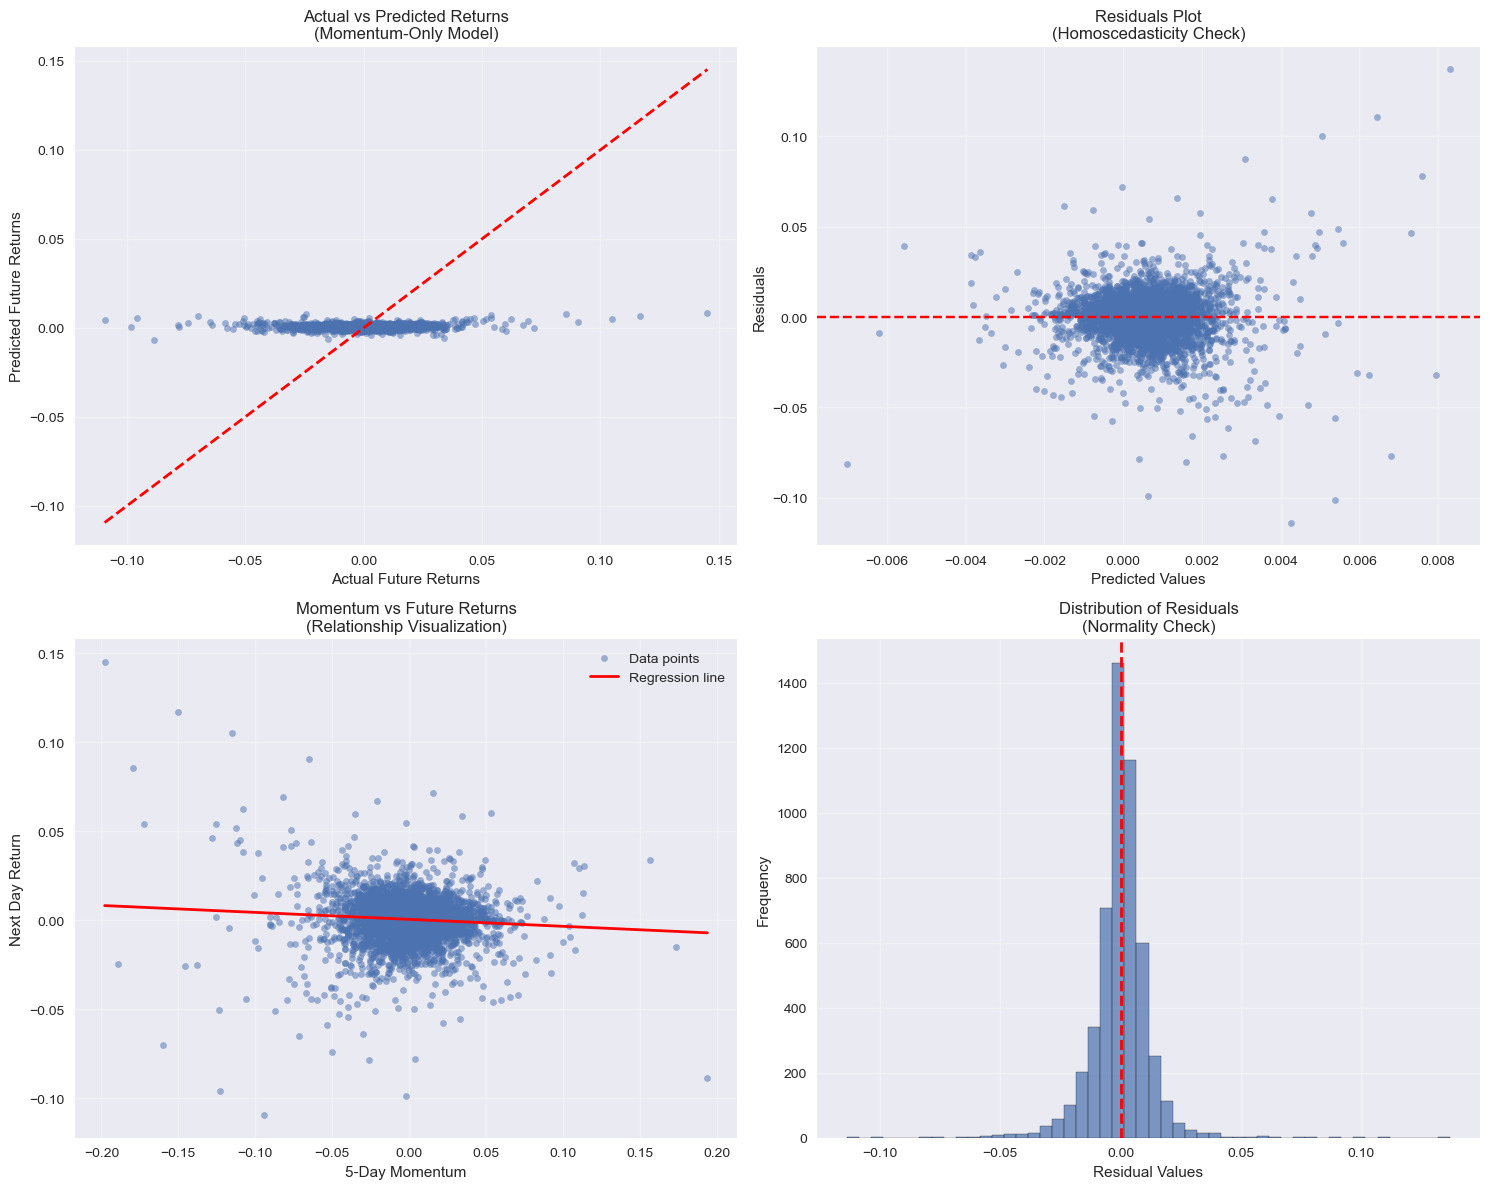

In [7]:
# Set up the plotting style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted Scatter
axes[0,0].scatter(y, y_pred, alpha=0.5, s=20)
axes[0,0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Future Returns')
axes[0,0].set_ylabel('Predicted Future Returns')
axes[0,0].set_title('Actual vs Predicted Returns\n(Momentum-Only Model)')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals Plot
residuals = y - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals Plot\n(Homoscedasticity Check)')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Momentum vs Future Returns (with regression line)
axes[1,0].scatter(X['momentum_5d'], y, alpha=0.5, s=20, label='Data points')
# Create regression line
x_line = np.linspace(X['momentum_5d'].min(), X['momentum_5d'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
axes[1,0].plot(x_line, y_line, 'r-', lw=2, label='Regression line')
axes[1,0].set_xlabel('5-Day Momentum')
axes[1,0].set_ylabel('Next Day Return')
axes[1,0].set_title('Momentum vs Future Returns\n(Relationship Visualization)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Distribution of Residuals
axes[1,1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Residual Values')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Residuals\n(Normality Check)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Enhanced results with more context
results_df = pd.DataFrame({
    'Date': df_clean['Date'],
    'SPY_Close': df_clean['SPY_Close'],  # Add price for reference
    'momentum_5d': df_clean['momentum_5d'],
    'actual_future_return': df_clean['target_future_return'],
    'predicted_return': y_pred,
    'prediction_error': y_pred - df_clean['target_future_return'].values,
    'absolute_error': abs(y_pred - df_clean['target_future_return'].values),
    'trading_signal': np.where(y_pred > 0, 'BUY', 'SELL')  # Simple strategy signal
})
results_df['correct_direction'] = (y * y_pred) > 0  # True if both same sign

results_df.to_csv('lin_reg_momentum_only_results.csv', index=False)
results_df.head(100)

,Date,SPY_Close,momentum_5d,actual_future_return,predicted_return,prediction_error,absolute_error,trading_signal,correct_direction
5,2005-01-10,80.962662,-0.010806,-0.006890,0.000989,0.007880,0.007880,BUY,False
6,2005-01-11,80.404800,-0.005469,0.003300,0.000781,-0.002519,0.002519,BUY,True
7,2005-01-12,80.670097,0.004745,-0.008012,0.000382,0.008394,0.008394,BUY,False
8,2005-01-13,80.023758,-0.008347,0.005271,0.000893,-0.004378,0.004378,BUY,True
9,2005-01-14,80.445580,-0.001689,0.010402,0.000633,-0.009769,0.009769,BUY,True
...,...,...,...,...,...,...,...,...,...
100,2005-05-26,81.997864,0.006371,0.001666,0.000319,-0.001348,0.001348,BUY,True
101,2005-05-27,82.134491,0.009487,-0.006404,0.000197,0.006601,0.006601,BUY,False
102,2005-05-31,81.608513,-0.002504,0.008537,0.000665,-0.007872,0.007872,BUY,True
103,2005-06-01,82.305229,0.008369,0.002158,0.000241,-0.001917,0.001917,BUY,True
